# Fase 1 - Baseline e Modelagem Classica

In [1]:
import polars as pl
import numpy as np 
from sklearn.model_selection import train_test_split

gold = pl.read_parquet("../data/processed/gold/gold_account_activity.parquet")
print(f"Shape: {gold.shape}")
print(f"Taxa de churne: {gold['is_churn'].mean():.1%}")

Shape: (25000, 21)
Taxa de churne: 9.0%


In [2]:
df  = gold.to_pandas()

train_val, test = train_test_split(
    df, test_size=0.15, stratify=df["is_churn"], random_state=42
)
train, val = train_test_split(
    train_val, test_size=0.15 / 0.85, stratify=train_val["is_churn"], random_state=42
)

print(f"Treino:     {len(train):>6} contas ({train['is_churn'].mean():.1%} churn)")
print(f"Validação:  {len(val):>6} contas ({val['is_churn'].mean():.1%} churn)")
print(f"Teste:      {len(test):>6} contas ({test['is_churn'].mean():.1%} churn)")

Treino:      17499 contas (9.0% churn)
Validação:    3751 contas (9.0% churn)
Teste:        3750 contas (9.0% churn)


In [3]:
target = "is_churn"

features_categoricas = ["faixa_etaria", "gender", "registered_via"]
features_booleanas = [
    "tem_cadastro", "tem_uso_registrado", "auto_renew_ultima",
    "desligou_auto_renovacao", "ja_cancelou"
]
features_numericas = [
    "tenure_cadastro_dias", "n_transacoes", "desconto_medio", "plano_dias_ultimo",
    "dias_desde_ultima_transacao", "total_secs_ultimo_mes", "variacao_uso_mes",
    "tendencia_uso_3m", "meses_ativos", "n_tickets_total", "n_tickets_ultimos_30d",
]
todas_features = features_categoricas + features_booleanas + features_numericas

X_train, y_train = train[todas_features], train[target]
X_val, y_val = val[todas_features], val[target]
X_test, y_test = test[todas_features], test[target]

print(f"Total de features: {len(todas_features)}")
print(f"  Categóricas: {len(features_categoricas)} | Booleanas: {len(features_booleanas)} | Numéricas: {len(features_numericas)}")

Total de features: 19
  Categóricas: 3 | Booleanas: 5 | Numéricas: 11


In [4]:
import numpy as np

print("Colunas com infinito:")
print(X_train[features_numericas].isin([np.inf, -np.inf]).sum())

Colunas com infinito:
tenure_cadastro_dias           0
n_transacoes                   0
desconto_medio                 0
plano_dias_ultimo              0
dias_desde_ultima_transacao    0
total_secs_ultimo_mes          0
variacao_uso_mes               0
tendencia_uso_3m               0
meses_ativos                   0
n_tickets_total                0
n_tickets_ultimos_30d          0
dtype: int64


In [5]:
for col in features_booleanas:
    for split_df in [train, val, test]:
        split_df[col] = split_df[col].astype("float64")

X_train, y_train = train[todas_features], train[target]
X_val, y_val = val[todas_features], val[target]
X_test, y_test = test[todas_features], test[target]

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

preprocessador = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), features_categoricas),
    ("bool", SimpleImputer(strategy="most_frequent"), features_booleanas),
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), features_numericas),
])

modelo_lr = Pipeline([
    ("preprocessador", preprocessador),
    ("classificador", LogisticRegression(max_iter=1000, random_state=42))
])

modelo_lr.fit(X_train, y_train)
print("Logistic Regression treinado")

Logistic Regression treinado


In [7]:
from sklearn.metrics import average_precision_score, precision_recall_curve

proba_val = modelo_lr.predict_proba(X_val)[:, 1]

pr_auc = average_precision_score(y_val, proba_val)
print(f"PR-AUC (validação): {pr_auc:.3f}")

precisions, recalls, thresholds = precision_recall_curve(y_val, proba_val)
f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-10)

# precisions/recalls têm 1 elemento a mais que thresholds (o último ponto não tem threshold associado)
melhor_idx = np.argmax(f2_scores[:-1])
melhor_threshold = thresholds[melhor_idx]

print(f"\nMelhor F2 (validação): {f2_scores[melhor_idx]:.3f} no threshold {melhor_threshold:.3f}")
print(f"  Precisão: {precisions[melhor_idx]:.1%} | Recall: {recalls[melhor_idx]:.1%}")
print(f"\nBaseline (regra de billing): F2 = 0.494 | Meta de produção: F2 >= 0.65")

PR-AUC (validação): 0.509

Melhor F2 (validação): 0.572 no threshold 0.090
  Precisão: 34.7% | Recall: 68.3%

Baseline (regra de billing): F2 = 0.494 | Meta de produção: F2 >= 0.65


In [8]:
from xgboost import XGBClassifier

X_train_xgb = X_train.copy()
X_val_xgb = X_val.copy()
X_test_xgb = X_test.copy()

for col in features_categoricas:
    X_train_xgb[col] = X_train_xgb[col].astype("category")
    X_val_xgb[col] = X_val_xgb[col].astype("category")
    X_test_xgb[col] = X_test_xgb[col].astype("category")

modelo_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05
)

modelo_xgb.fit(X_train_xgb, y_train)
print("XGBoost treinado")


XGBoost treinado


In [9]:
from sklearn.metrics import average_precision_score, precision_recall_curve

proba_val_xgb = modelo_xgb.predict_proba(X_val_xgb)[:, 1]

pr_auc_xgb = average_precision_score(y_val, proba_val_xgb)
print(f"PR-AUC (validação) - XGBoost: {pr_auc_xgb:.3f}")

precisions_xgb, recalls_xgb, thresholds_xgb = precision_recall_curve(y_val, proba_val_xgb)
f2_scores_xgb = (5 * precisions_xgb * recalls_xgb) / (4 * precisions_xgb + recalls_xgb + 1e-10)

melhor_idx_xgb = np.argmax(f2_scores_xgb[:-1])
melhor_threshold_xgb = thresholds_xgb[melhor_idx_xgb]

print(f"\nMelhor F2 (validação) - XGBoost: {f2_scores_xgb[melhor_idx_xgb]:.3f} no threshold {melhor_threshold_xgb:.3f}")
print(f"  Precisão: {precisions_xgb[melhor_idx_xgb]:.1%} | Recall: {recalls_xgb[melhor_idx_xgb]:.1%}")

print(f"\nComparação:")
print(f"  Baseline:             F2 = 0.494")
print(f"  Logistic Regression:  F2 = 0.572")
print(f"  XGBoost:              F2 = {f2_scores_xgb[melhor_idx_xgb]:.3f}")
print(f"  Meta de produção:     F2 >= 0.65")

PR-AUC (validação) - XGBoost: 0.590

Melhor F2 (validação) - XGBoost: 0.614 no threshold 0.142
  Precisão: 45.7% | Recall: 67.2%

Comparação:
  Baseline:             F2 = 0.494
  Logistic Regression:  F2 = 0.572
  XGBoost:              F2 = 0.614
  Meta de produção:     F2 >= 0.65


In [10]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "min_child_weight": [1, 5, 10],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
}

busca = RandomizedSearchCV(
    XGBClassifier(enable_categorical=True, eval_metric="aucpr", random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1,
)

busca.fit(X_train_xgb, y_train)
print(f"Melhor PR-AUC (validação cruzada): {busca.best_score_:.3f}")
print(f"Melhores parâmetros: {busca.best_params_}")

modelo_xgb_tuned = busca.best_estimator_

Melhor PR-AUC (validação cruzada): 0.605
Melhores parâmetros: {'subsample': 0.85, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.85}


In [11]:
proba_val_tuned = modelo_xgb_tuned.predict_proba(X_val_xgb)[:, 1]

pr_auc_tuned = average_precision_score(y_val, proba_val_tuned)
print(f"PR-AUC (validação) - XGBoost ajustado: {pr_auc_tuned:.3f}")

precisions_t, recalls_t, thresholds_t = precision_recall_curve(y_val, proba_val_tuned)
f2_scores_t = (5 * precisions_t * recalls_t) / (4 * precisions_t + recalls_t + 1e-10)

melhor_idx_t = np.argmax(f2_scores_t[:-1])
melhor_threshold_t = thresholds_t[melhor_idx_t]

print(f"\nMelhor F2 (validação) - XGBoost ajustado: {f2_scores_t[melhor_idx_t]:.3f} no threshold {melhor_threshold_t:.3f}")
print(f"  Precisão: {precisions_t[melhor_idx_t]:.1%} | Recall: {recalls_t[melhor_idx_t]:.1%}")

print(f"\nComparação final:")
print(f"  Baseline:                  F2 = 0.494")
print(f"  Logistic Regression:       F2 = 0.572")
print(f"  XGBoost (padrão):          F2 = 0.614")
print(f"  XGBoost (ajustado):        F2 = {f2_scores_t[melhor_idx_t]:.3f}")
print(f"  Meta de produção:          F2 >= 0.65")

PR-AUC (validação) - XGBoost ajustado: 0.596

Melhor F2 (validação) - XGBoost ajustado: 0.626 no threshold 0.129
  Precisão: 44.2% | Recall: 69.8%

Comparação final:
  Baseline:                  F2 = 0.494
  Logistic Regression:       F2 = 0.572
  XGBoost (padrão):          F2 = 0.614
  XGBoost (ajustado):        F2 = 0.626
  Meta de produção:          F2 >= 0.65


In [12]:
param_dist_v2 = {
    "n_estimators": [100, 200, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "min_child_weight": [1, 5, 10],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "scale_pos_weight": [1, 3, 5, 8, 10],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10],
}

busca_v2 = RandomizedSearchCV(
    XGBClassifier(enable_categorical=True, eval_metric="aucpr", random_state=42),
    param_distributions=param_dist_v2,
    n_iter=50,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1,
)

busca_v2.fit(X_train_xgb, y_train)
print(f"Melhor PR-AUC (validação cruzada): {busca_v2.best_score_:.3f}")
print(f"Melhores parâmetros: {busca_v2.best_params_}")

modelo_xgb_v2 = busca_v2.best_estimator_

Melhor PR-AUC (validação cruzada): 0.605
Melhores parâmetros: {'subsample': 1.0, 'scale_pos_weight': 1, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


In [13]:
proba_val_v2 = modelo_xgb_v2.predict_proba(X_val_xgb)[:, 1]

pr_auc_v2 = average_precision_score(y_val, proba_val_v2)
precisions_v2, recalls_v2, thresholds_v2 = precision_recall_curve(y_val, proba_val_v2)
f2_scores_v2 = (5 * precisions_v2 * recalls_v2) / (4 * precisions_v2 + recalls_v2 + 1e-10)
melhor_idx_v2 = np.argmax(f2_scores_v2[:-1])

print(f"PR-AUC (validação): {pr_auc_v2:.3f}")
print(f"Melhor F2 (validação): {f2_scores_v2[melhor_idx_v2]:.3f} no threshold {thresholds_v2[melhor_idx_v2]:.3f}")
print(f"  Precisão: {precisions_v2[melhor_idx_v2]:.1%} | Recall: {recalls_v2[melhor_idx_v2]:.1%}")

PR-AUC (validação): 0.600
Melhor F2 (validação): 0.629 no threshold 0.146
  Precisão: 46.5% | Recall: 68.9%


In [14]:
from sklearn.metrics import precision_score, recall_score, fbeta_score

threshold_final = thresholds_v2[melhor_idx_v2]

proba_test = modelo_xgb_v2.predict_proba(X_test_xgb)[:, 1]
y_pred_test = (proba_test >= threshold_final).astype(int)

pr_auc_teste = average_precision_score(y_test, proba_test)
f2_teste = fbeta_score(y_test, y_pred_test, beta=2)
precisao_teste = precision_score(y_test, y_pred_test)
recall_teste = recall_score(y_test, y_pred_test)

print("=== Avaliação final no conjunto de TESTE (nunca visto pelo modelo nem pela busca de hiperparâmetro) ===")
print(f"PR-AUC:    {pr_auc_teste:.3f}")
print(f"F2:        {f2_teste:.3f}")
print(f"Precisão:  {precisao_teste:.1%}")
print(f"Recall:    {recall_teste:.1%}")
print(f"\n(threshold usado: {threshold_final:.3f} — escolhido na validação, aplicado sem reajuste no teste)")

=== Avaliação final no conjunto de TESTE (nunca visto pelo modelo nem pela busca de hiperparâmetro) ===
PR-AUC:    0.581
F2:        0.601
Precisão:  44.9%
Recall:    65.6%

(threshold usado: 0.146 — escolhido na validação, aplicado sem reajuste no teste)


In [15]:
features_sem_auto_renew = [f for f in todas_features if f != "auto_renew_ultima"]

X_train_robusto = X_train_xgb[features_sem_auto_renew]
X_val_robusto = X_val_xgb[features_sem_auto_renew]
X_test_robusto = X_test_xgb[features_sem_auto_renew]

modelo_robusto = XGBClassifier(**busca_v2.best_params_, enable_categorical=True, eval_metric="aucpr", random_state=42)
modelo_robusto.fit(X_train_robusto, y_train)

proba_val_robusto = modelo_robusto.predict_proba(X_val_robusto)[:, 1]
precisions_r, recalls_r, thresholds_r = precision_recall_curve(y_val, proba_val_robusto)
f2_scores_r = (5 * precisions_r * recalls_r) / (4 * precisions_r + recalls_r + 1e-10)
melhor_idx_r = np.argmax(f2_scores_r[:-1])
threshold_r = thresholds_r[melhor_idx_r]

proba_test_robusto = modelo_robusto.predict_proba(X_test_robusto)[:, 1]
y_pred_test_robusto = (proba_test_robusto >= threshold_r).astype(int)
f2_teste_robusto = fbeta_score(y_test, y_pred_test_robusto, beta=2)

print(f"F2 (teste) SEM auto_renew_ultima: {f2_teste_robusto:.3f}")
print(f"F2 (teste) COM auto_renew_ultima: {f2_teste:.3f}")
print(f"Queda: {(f2_teste - f2_teste_robusto):.3f} ({(1 - f2_teste_robusto/f2_teste):.1%} de perda relativa)")

F2 (teste) SEM auto_renew_ultima: 0.568
F2 (teste) COM auto_renew_ultima: 0.601
Queda: 0.032 (5.4% de perda relativa)


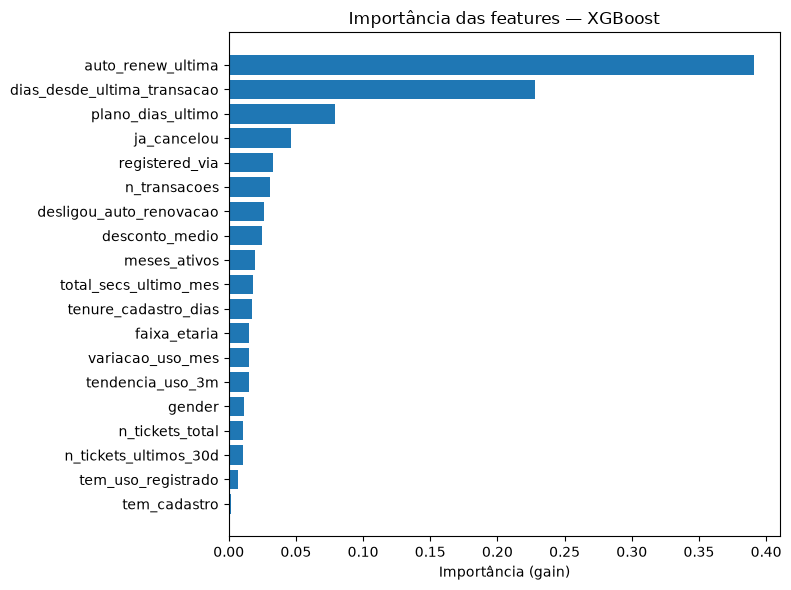

auto_renew_ultima              0.3908
dias_desde_ultima_transacao    0.2281
plano_dias_ultimo              0.0790
ja_cancelou                    0.0462
registered_via                 0.0332
n_transacoes                   0.0309
desligou_auto_renovacao        0.0260
desconto_medio                 0.0249
meses_ativos                   0.0195
total_secs_ultimo_mes          0.0178
tenure_cadastro_dias           0.0170
faixa_etaria                   0.0154
variacao_uso_mes               0.0151
tendencia_uso_3m               0.0148
gender                         0.0115
n_tickets_total                0.0109
n_tickets_ultimos_30d          0.0106
tem_uso_registrado             0.0067
tem_cadastro                   0.0016


In [16]:
import matplotlib.pyplot as plt

importancias = modelo_xgb_v2.feature_importances_
nomes_features = X_train_xgb.columns
ordem = importancias.argsort()[::-1]

plt.figure(figsize=(8, 6))
plt.barh(range(len(importancias)), importancias[ordem][::-1])
plt.yticks(range(len(importancias)), [nomes_features[i] for i in ordem][::-1])
plt.xlabel("Importância (gain)")
plt.title("Importância das features — XGBoost")
plt.tight_layout()
plt.show()

for i in ordem:
    print(f"{nomes_features[i]:30s} {importancias[i]:.4f}")

In [18]:
import joblib
import json

joblib.dump(modelo_xgb_v2, "../data/processed/models/xgboost_churn_v1.joblib")

metadata = {
    "features_categoricas": features_categoricas,
    "features_booleanas": features_booleanas,
    "features_numericas": features_numericas,
    "threshold": float(threshold_final),
    "f2_teste": float(f2_teste),
    "pr_auc_teste": float(pr_auc_teste),
}
with open("../data/processed/models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Modelo e metadata salvos.")

Modelo e metadata salvos.
